[Signal Names] MAYBE WROING

SamplePeriod: 50 μs

SampleTime: 10.237 s

signal1  ID:0x23040000  Name:Speed loop reference  Unit:rpm

signal2  ID:0x60690000  Name:Speed loop feedback  Unit:rpm

End Time: 8.00359 s
Sampling Frequency: 10.0 kHz

index_begin 1
index_end -53372
time_begin: 0.0001 s
time_end 2.6663900000000007 s

Max reference speed: 100.0
Max measured speed: 94.9209
Min reference speed: -100.0
Min measured speed: -94.7508

Time Span: 2.66234 s


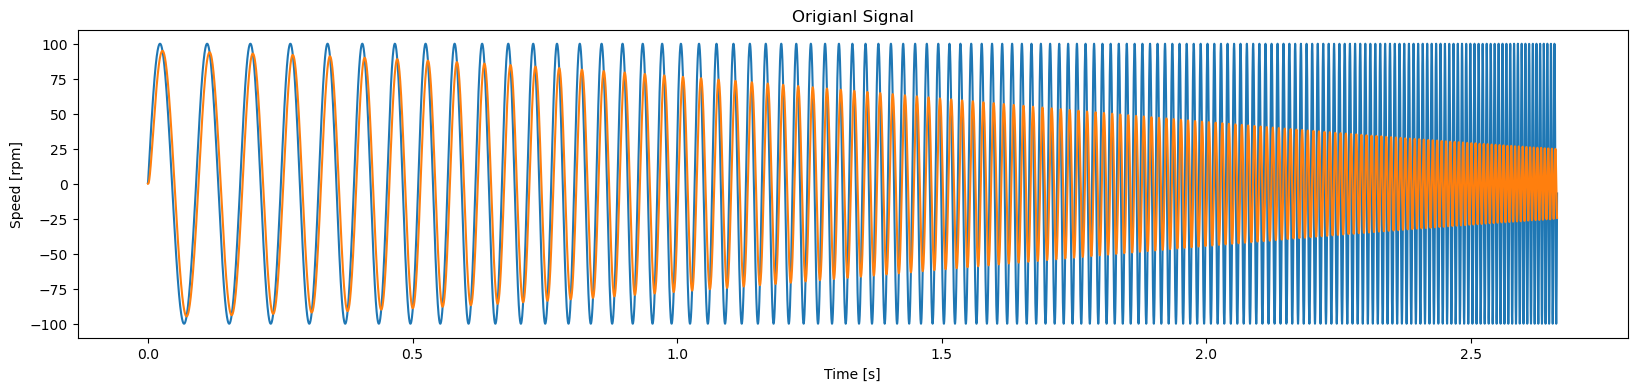

In [1]:
%reset -f
import pandas as pd
from pylab import plt, np
from pylab import fft
import math
%matplotlib inline

# Target file name
# fname = 'data/SweepingData.txt'
# fname = 'data/SweepingData.txt'
fname = 'data/SpeedSweepingData.txt'
max_freq = 300 # [Hz]

# Read name and meta data
signal_names = []
with open(fname, 'r', encoding='gb2312') as f:
    for _ in range(5):
        line = f.readline()
        print(line)
        if 'Unit' in line:
            signal_name = line[line.find('Name')+5 : line.find('Unit')]
            signal_names.append(signal_name)

# read data as Data Frame
df = pd.read_csv(fname, skiprows=7, sep='\s+', encoding='gb2312', names=['Time(s)', signal_names[0], signal_names[1]])

# Unpack as Series
time  = df['Time(s)']
x_ref = df[signal_names[0]]
x_qep = df[signal_names[1]] #+ 100 # add dc offset for test

# Basic DFT parameters
# N = df.shape[0]
Ts = df['Time(s)'][1] - df['Time(s)'][0]
samplingFreq = 1/Ts
EndTime = df['Time(s)'].iloc[-1]
print('End Time:', EndTime, 's')
print('Sampling Frequency:', samplingFreq*1e-3, 'kHz')
# print('Number of Points:', N)
print()

# Plot signal in time domain
for index, value in enumerate(x_ref):
    if value!=x_ref.iloc[0]:
        index_begin = index
        time_begin = index*Ts
        break
for index, value in enumerate(x_ref[::-1]):
    if value!=x_ref.iloc[-1]:
        index_end = -index
        time_end = EndTime - index*Ts
        break
print('index_begin', index_begin)
print('index_end', index_end)
print('time_begin:', time_begin, 's')
print('time_end', time_end,   's')
time  = time [index_begin:index_end]
x_ref = x_ref[index_begin:index_end]
x_qep = x_qep[index_begin:index_end]
plt.figure(figsize=(20,4))
plt.title('Origianl Signal')
plt.xlabel('Time [s]')
plt.ylabel('Speed [rpm]')
plt.plot(time, x_ref, label='ref')
plt.plot(time, x_qep, label='qep')

# plt.xlim([0, 8/target_Hz])
print()
print('Max reference speed:', max(x_ref))
print('Max measured speed:', max(x_qep))
print('Min reference speed:', min(x_ref))
print('Min measured speed:', min(x_qep))


print()
TimeSpan = time.iloc[-1]
print('Time Span:', TimeSpan, 's')

Frequency Resolution: 11.00 Hz | Max Amplitude: 94.85 rpm | Corresponding Frequency: 11.00 Hz
Frequency Resolution: 12.00 Hz | Max Amplitude: 93.88 rpm | Corresponding Frequency: 12.00 Hz
Frequency Resolution: 13.00 Hz | Max Amplitude: 92.95 rpm | Corresponding Frequency: 13.00 Hz
Frequency Resolution: 14.01 Hz | Max Amplitude: 91.99 rpm | Corresponding Frequency: 14.01 Hz
Frequency Resolution: 15.02 Hz | Max Amplitude: 91.01 rpm | Corresponding Frequency: 15.02 Hz
Frequency Resolution: 16.00 Hz | Max Amplitude: 89.97 rpm | Corresponding Frequency: 16.00 Hz
Frequency Resolution: 17.01 Hz | Max Amplitude: 88.94 rpm | Corresponding Frequency: 17.01 Hz
Frequency Resolution: 18.02 Hz | Max Amplitude: 87.88 rpm | Corresponding Frequency: 18.02 Hz
Frequency Resolution: 19.01 Hz | Max Amplitude: 86.81 rpm | Corresponding Frequency: 19.01 Hz
Frequency Resolution: 20.00 Hz | Max Amplitude: 85.73 rpm | Corresponding Frequency: 20.00 Hz
Frequency Resolution: 21.01 Hz | Max Amplitude: 84.67 rpm | 

ValueError: x and y must have same first dimension, but have shapes (2,) and (1,)

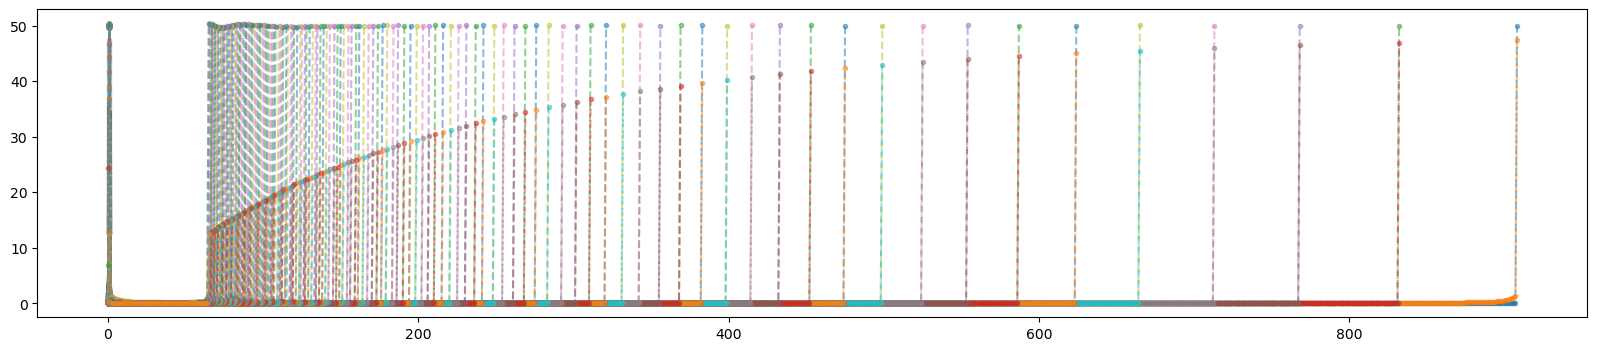

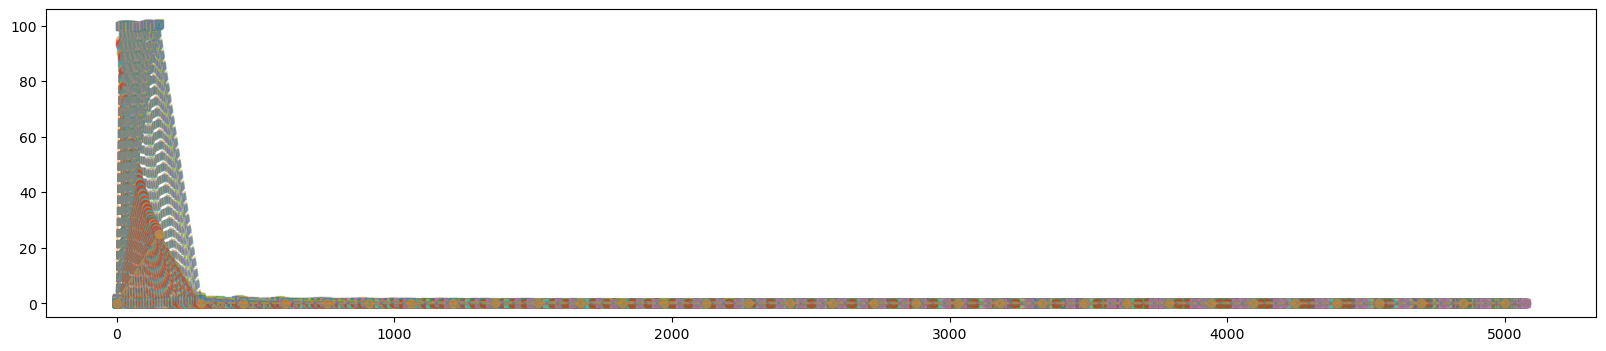

In [5]:
list_qep_max_amplitude = []
list_qep_max_frequency = []
list_ref_max_amplitude = []
list_ref_max_frequency = []

index_single_tone_begin = 0
index_single_tone_end = 0
# max_freq = 100 # debug



######
# 原脚本的循环是从2Hz开始，这是因为扫频扫1Hz，没有什么意义，1s太长了，但是这就牵扯到一个问题
# 怎么把1s后的数据拿出来，而不是简单的数据赋值，以后要么规定从2Hz开始扫吧！
# 这样的话1就要改成2了
######
sweepingFreq_begin = 11 # [Hz]
######



for freq in range(sweepingFreq_begin, max_freq): # datum point at 1 Hz is absent
    period = 1/freq
    index_single_tone_begin = index_single_tone_end
    index_single_tone_end = index_single_tone_begin + int(period/Ts)
        
    ST_time  =  time[index_single_tone_begin:index_single_tone_end]
    ST_x_ref = x_ref[index_single_tone_begin:index_single_tone_end]
    ST_x_qep = x_qep[index_single_tone_begin:index_single_tone_end]

    # x_ref_dft = fft(ST_x_ref)
    # x_qep_dft = fft(ST_x_qep)

    if len(ST_x_ref) > 0 and len(ST_x_qep) > 0:
        x_ref_dft = fft(ST_x_ref)
        x_qep_dft = fft(ST_x_qep)
    else:
        print(f"Skipping FFT for frequency {freq} due to insufficient data points.")
    # Do DFT (Raw)
    N = len(ST_time)
    plt.figure(1, figsize=(20,4))
    plt.plot(abs(x_ref_dft)/N, '.--', alpha=0.5, label='x_ref-dft');
    plt.plot(abs(x_qep_dft)/N, '.--', alpha=0.5, label='x_qep-dft');
    #     plt.legend(loc='center')

    # Convert raw DFT results into human-friendly forms
    resolution = samplingFreq/N # [Hz]
    Neff = math.ceil(N/2) # number of effective points
                          # 其实理论上来说，这里是比较复杂的，当N为偶数的时候，奈奎斯特频率就是采样频率的二分之一？当N为奇数的时候，还会多出一个分量，这个分量和直流分量是一对，具体我忘了……可能有错
    x_ref_hat = np.append(x_ref_dft[0]/N, 2*x_ref_dft[1:Neff+1]/N)  # 原始复数dft结果（双边变单边，除了直流分量，其他分量全部要乘以2）
    x_qep_hat = np.append(x_qep_dft[0]/N, 2*x_qep_dft[1:Neff+1]/N)

    # Plot DFT for human to read
    plt.figure(2, figsize=(20,4))
    plt.plot(np.array(list(range(0, Neff+1)))*resolution, abs(x_ref_hat), '--s', alpha=0.5, label='ref');
    plt.plot(np.array(list(range(0, Neff+1)))*resolution, abs(x_qep_hat), '--o', alpha=0.5, label='qep');

    # qep related data collection
    max_amplitude = max(abs(x_qep_hat));      list_qep_max_amplitude.append(max_amplitude)
    max_index     = np.argmax(abs(x_qep_hat))
    max_frequency = (max_index+0)*resolution; list_qep_max_frequency.append(max_frequency)

    print(f'Frequency Resolution: {resolution:.2f} Hz', end=' | ')
    print(f'Max Amplitude: {max_amplitude:.2f} rpm', end=' | ')
    print(f'Corresponding Frequency: {max_frequency:.2f} Hz')

    # ref related data collection
    max_amplitude = max(abs(x_ref_hat));      list_ref_max_amplitude.append(max_amplitude)
    max_index     = np.argmax(abs(x_ref_hat))
    max_frequency = (max_index+0)*resolution; list_ref_max_frequency.append(max_frequency)
    
    # stop and inspect
    #     a = input()
    #     print(freq, 'Hz')

plt.figure(1)
plt.title('Double Sided DFT Abs')

plt.figure(2)
plt.title('Single Sided DFT Abs versus Freq')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Speed [rpm]')
plt.xlim([0, 100])
freq

ValueError: x and y must have same first dimension, but have shapes (298,) and (141,)

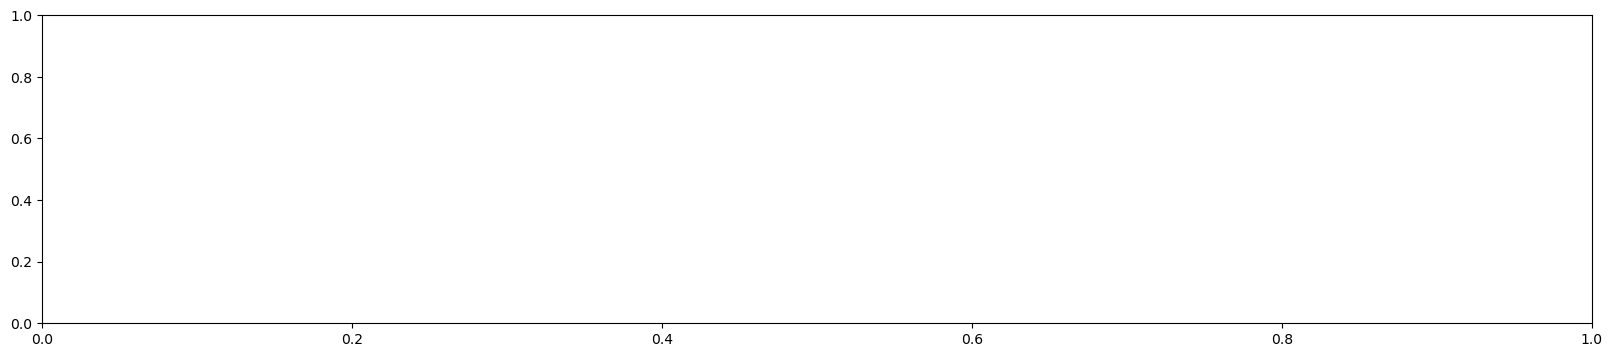

In [6]:
plt.figure(3, figsize=(20,4))
if max_freq>100:
    list_ref_max_frequency = list(range(2, max_freq))
    list_qep_max_frequency = list(range(2, max_freq))


# # TODO：修复bug，这里freq缺1Hz    
# # Warning：这里我手插如一个1Hz的信号，这么干是不对的！！！可是为了画图，先这么干吧
# list_ref_max_frequency.insert(0, 1)
# list_qep_max_frequency.insert(0, 1)
# plt.plot(list_ref_max_frequency, list_ref_max_amplitude, '--')
# plt.plot(list_qep_max_frequency, list_qep_max_amplitude, '--')
# plt.xlabel('Freq [Hz]')
# plt.ylabel('Speed [rpm]')

################################# 2Hz
plt.figure(3, figsize=(20,4))
if max_freq>500:
    list_ref_max_frequency = list(range(2, max_freq))
    list_qep_max_frequency = list(range(2, max_freq))

plt.plot(list_ref_max_frequency, list_ref_max_amplitude, '--')
plt.plot(list_qep_max_frequency, list_qep_max_amplitude, '--')
plt.xlabel('Freq [Hz]')
plt.ylabel('Speed [rpm]')

Text(0, 0.5, 'closed-loop transfer function amplitude [1]')

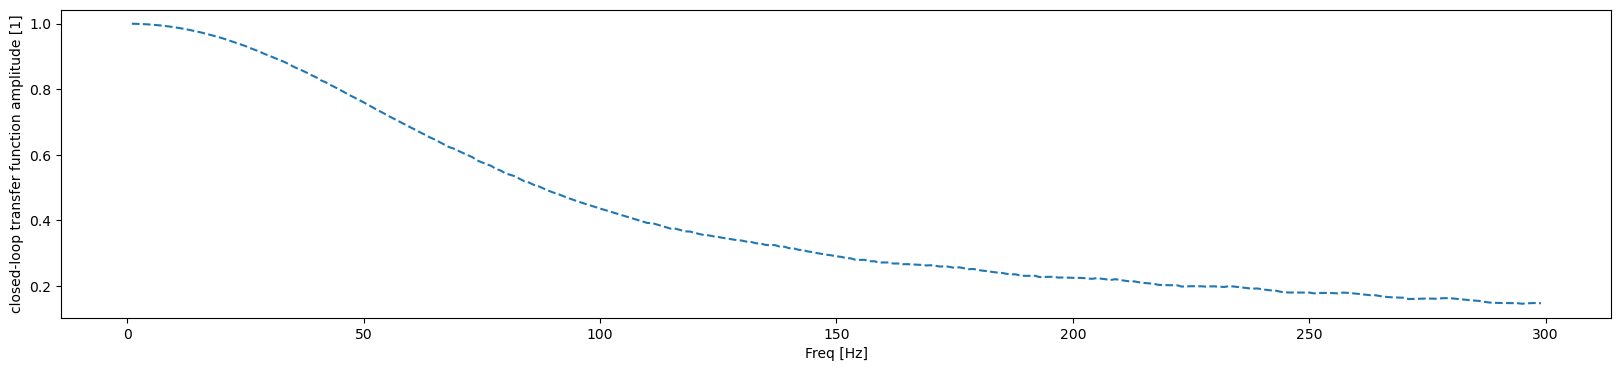

In [4]:
plt.figure(4, figsize=(20,4))
closed_loop_transfer_function = [qep/ref for ref, qep in zip(list_ref_max_amplitude, list_qep_max_amplitude)]
plt.plot(list_qep_max_frequency, closed_loop_transfer_function, '--')
plt.xlabel('Freq [Hz]')
plt.ylabel('closed-loop transfer function amplitude [1]')

Text(0, 0.5, 'closed-loop transfer function amplitude [dB]')

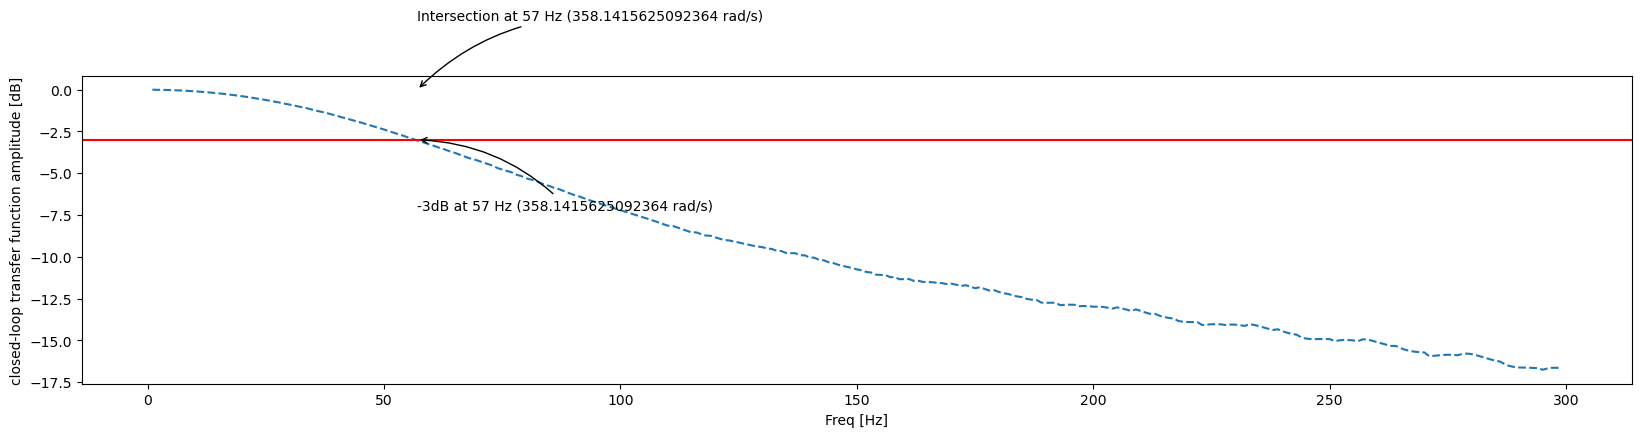

In [5]:
plt.figure(4, figsize=(20,4))
# closed_loop_transfer_function = [qep/ref for ref, qep in zip(list_ref_max_amplitude, list_qep_max_amplitude)]
dB_values = [20*np.log10(el) for el in closed_loop_transfer_function]
plt.plot(list_qep_max_frequency, dB_values, '--')

# Add -3dB line
plt.axhline(y=-3, color='r', linestyle='-')

# Find -3dB point
for i, dB in enumerate(dB_values):
    if dB < -3:
        break
freq_at_minus_3dB = list_qep_max_frequency[i]

# Convert to rad/s
freq_at_minus_3dB_rad_s = freq_at_minus_3dB * 2 * np.pi

# Annotate -3dB point
plt.annotate(f'-3dB at {freq_at_minus_3dB} Hz ({freq_at_minus_3dB_rad_s} rad/s)', 
             xy=(freq_at_minus_3dB, -3), xycoords='data',
             xytext=(0, -50), textcoords='offset points',
             arrowprops=dict(arrowstyle="->",
                             connectionstyle="arc3,rad=.2"))

# Annotate intersection on x-axis
plt.annotate(f'Intersection at {freq_at_minus_3dB} Hz ({freq_at_minus_3dB_rad_s} rad/s)', 
             xy=(freq_at_minus_3dB, 0), xycoords='data',
             xytext=(0, 50), textcoords='offset points',
             arrowprops=dict(arrowstyle="->",
                             connectionstyle="arc3,rad=.2"))

plt.xlabel('Freq [Hz]')
plt.ylabel('closed-loop transfer function amplitude [dB]')